# Solphin Main Tutorial Notebook

At current this is only tested in inorganic semiconductor (non-perovskite) photovoltaic materials.

Calculating the \<name\> figure of merit requires various data characterising a material's optoelectronic properties. \<Placeholder\> provides methods to automate/assist calculating these properties using VASP (the Vienna Ab-initio Simulation Package).

In [3]:
#import the required modules

import solphin.db_fom as db_fom
import solphin.pv_fom as pv_fom
import solphin.db_plotting as db_plotting
import solphin.final_results as final_results
import solphin.vasp_inputs as vasp_inputs
import solphin.optics as optics
import solphin.spectral as spectral
import solphin.dos_plotting as dos_plotting
import numpy as np # version - 1.26.4

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Using Solphin to generate VASP input files

### Geometry Optimisation / Relaxation

The initial step of any DFT structural property study is a geometry optimisation to find the lowest energy position of the atoms in your system. For this you need:

- A starting structure, this can be obtained from the ICSD, the Materials Project, or experimental studies. Placeholder currently accepts  the VASP POSCAR/CONTCAR, .cif, .xyz, or .json formats.

- Appropiate values for the `ENCUT` and `KSPACING` for your system. Convergence testing is the commonly used method of determining the appropiate values, see [here](https://github.com/kavanase/vaspup2.0).

- To choose a functional. It is recommended to use hybrid DFT (HSE06 or PBE0) to achieve publishable results.

In [4]:
# Set the structure filename and calculation settings

filename = 'cdte/relaxed_primitive_POSCAR'
relax_directory = 'relax'                    # The folder you want to run the calculation in
functional = 'HSE06'                         # The DFT functional
encut = 450                                  # Plane-wave energy cutoff                
kspacing = 0.2                               # k-point sampling density


# Load the structure
structure = vasp_inputs.read_structure_pmg(filename)

# Generate the calculations
vasp_inputs.write_vasp_calculation(structure=structure, recipe=functional, out_dir=relax_directory, patches=['relax_cell', 'tight_relax'], user_incar_settings={"KSPACING": kspacing, "ENCUT": encut})

### Electronic Density of States and Optical Absorption

* This calculation produces the optoelectronic data we need.

* This time the structure we feed in is the `CONTCAR` generated in the previous step, which contains our "relaxed" or "optimised" structure.

* To get the most accurate results, the shape of the Density of States and optical absorption spectrum should be sufficiently converged with respect to `KSPACING` and `NBANDS`.

In [5]:
#Set the input structure (the output of the previous step) and the output directory for the current step
contcar = f'{relax_directory}/CONTCAR'
optics_directory = 'optics'

# Load the structure
structure = vasp_inputs.read_structure_pmg(contcar)

# Generate the calculation
vasp_inputs.write_vasp_calculation(structure=structure, recipe=functional, out_dir=optics_directory, patches=["optics"], user_incar_settings={"KSPACING": kspacing, "ENCUT": encut, "ISPIN": 1, "ISMEAR": -5, "SIGMA": 0.02, "LORBIT": 14})

#### Analysing the Results

##### Electronic Density of States

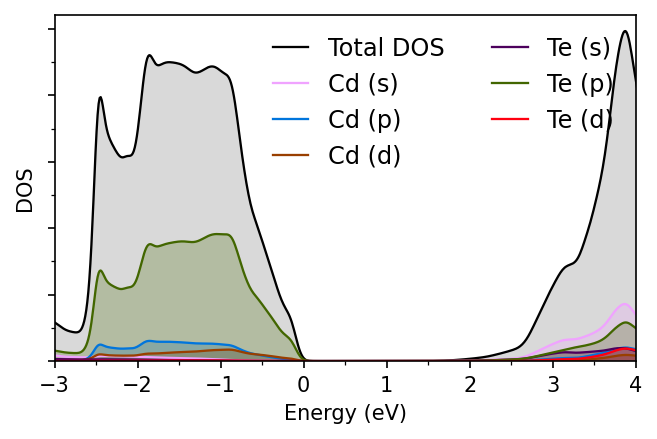

In [6]:
dos_plotting.plot_dos(filename=f'{optics_directory}/vasprun.xml', xmin=-3, xmax=4, gaussian=0.05, save=False)

##### Optical Absorption Spectrum

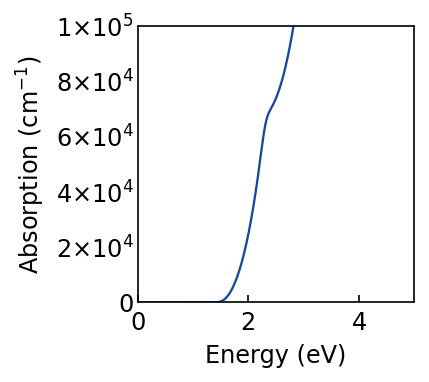

In [7]:
optics.plot_absorption(filename=f'{optics_directory}/vasprun.xml', xmax=5)

## Calculating the SLME and Blank et al. metrics

In [8]:
# Generates a n_real.dat for use in SLME and Blank et al

filename = f'{optics_directory}/vasprun.xml'
optics.generate_n_real(filename, optics_directory)

TypeError: generate_n_real() takes 1 positional argument but 2 were given

In [9]:
# Use adapted blank metric code to generate flat_eta_out & lamb_eta_out

spectrum_type = "AM1.5" # One of "AM1.5", "Fluorescent", "Blue LED", "Green LED", "Red LED", "White LED", "IR LED", "Photopic"

spectrum = db_fom.load_spectrum(spectrum_type=spectrum_type)
photon_spectrum = db_fom.convert_spectrum(spectrum)          #Fix spectrum read error and work out which spectrum is required. 
optics.blank_calculate(photon_spectrum, optics_directory)

/home/owner/scripts/PV-FoM/solphin/optics.py:179: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  abs_data = pd.read_table(f'{folder}/absorption.dat', delim_whitespace=True,
/home/owner/scripts/PV-FoM/solphin/optics.py:181: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  n_data = pd.read_table(f'{folder}/n_real.dat', delim_whitespace=True,
/home/owner/scripts/PV-FoM/solphin/optics.py:149: RuntimeWarning: invalid value encountered in divide
  phibb = 2*np.divide(np.divide(np.multiply(E,E),((h**3)*(c**2))),(np.exp(E/kT)-1))
/home/owner/scripts/PV-FoM/solphin/optics.py:132: RuntimeWarning: invalid value encountered in multiply
  T = np.exp((-x)) - np.multiply(x, np.exp((-x))) + (x**2*sc.exp1(x))


In [ ]:
optics.blank_calculate(photon_spectrum, folder)

In [9]:
dir = 0.14# Direct Bandgap of your material from the band_std
indir= 0.15 # Indirect Bandgap of your material from the band_std (if none given use the direct bandgap twice)

#Get energy and absorption form absorption.dat. Get from sumo-optplot
abs_file = 'absorption_Imm2_Cu2GeSe3.dat'

In [6]:
direct = 0.14# Direct Bandgap of your material from the band_std
indir= 0.15 # Indirect Bandgap of your material from the band_std (if none given use the direct bandgap twice)      #Wrap around sumo-bandstats?

#Get energy and absorption form absorption.dat. Get from sumo-optplot
abs_file = f'{optics_directory}/absorption.dat'

spectral_average, spectral_dispersion = spectral.generate_spectral_parameters(abs_file, spectrum, E_gap=direct)
print(spectral_average, spectral_dispersion)

86490.91561841572 nan


/root/Linux_Project/Figure_of_merit/fom_placeholder/placeholder/spectral.py:91: RuntimeWarning: divide by zero encountered in log
  log_alpha = [np.log(a) for a in filtered_abs_coff]
/root/Linux_Project/Figure_of_merit/fom_placeholder/placeholder/spectral.py:100: RuntimeWarning: invalid value encountered in scalar subtract
  numerator_x = list(irr * (log_a - log_alpha_bar) ** 2 for irr, log_a in zip(matched_irradiance, log_alpha))
/root/miniconda3/envs/toolbox/lib/python3.9/site-packages/scipy/integrate/_quadrature.py:808: RuntimeWarning: invalid value encountered in scalar subtract
  result += alpha*y[slice1] + beta*y[slice2] - eta*y[slice3]


### SLME

In [10]:

energy, alpha_cm = spectral.load_absorption(abs_file)

print(energy)

#Test to see if this works for a specific thickness
data = slme.slme(energy, alpha_cm, direct, indir, thickness=1e-05, absorbance_in_inverse_centimeters=True)

print(data)

# Now run for multiple thicknesses 

thickness = np.logspace(-8, -3, 100, endpoint=True)
effSlm = []

for i in thickness:
    eff = data = slme.slme(energy, alpha_cm, direct, indir, thickness=i, absorbance_in_inverse_centimeters=True)
    effSlm.append(eff)

# Plot the SLME results

ax = plt.axes()
plt.plot(thickness, effSlm)
plt.xscale('log')
plt.margins(x=0)
plt.ylim([0, 35])
plt.xlabel('Film Thickness / m', labelpad=5)
plt.ylabel('Max PV Efficiency $(\eta_{Max})$ / %')
ax.set_aspect(0.06)
plt.savefig('slme.pdf', format='pdf')

# You should have ran the Blank_Metric module from github - Chris Savory and have flat_eta_out and lamb_eta_out files

print('Running full Blank SLME plot')

lamb = np.loadtxt('lamb_eta_out', skiprows=0)
thickness_lamb = lamb[:,0]
eff_lamb = [x*100 for x in lamb[:,1]]

flat = np.loadtxt('flat_eta_out', skiprows=0)
thickness_flat = flat[:,0]
eff_flat = [x*100 for x in flat [:,1]]

ax = plt.axes()
plt.plot(thickness, effSlm, label = 'SLME')
plt.plot(thickness_lamb, eff_lamb, label = 'Blank et al, Lambertian Surface')
plt.plot(thickness_flat, eff_flat, label = 'Blank et al, Flat Surface')
plt.xscale('log')
plt.margins(x=0)
plt.ylim([0, 35])
ax.set_aspect(0.06)
plt.legend()
plt.savefig('pveff.pdf', format='pdf')

<>:27: SyntaxWarning: invalid escape sequence '\e'
<>:27: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_966716/3219093630.py:27: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('Max PV Efficiency $(\eta_{Max})$ / %')
/tmp/ipykernel_966716/3219093630.py:27: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('Max PV Efficiency $(\eta_{Max})$ / %')


NameError: name 'abs_file' is not defined

## Obtaining the Detailed Balance and Shockley-Queisser Limit

By supplying a band gap (eV) and operating temperature (K), the Detailed Balance results can be obtained and plotted.

In [2]:
# Define the operating temperature of the cell and Fundamental band gap (?)

Tcell = 300             # Operating Temperature
Egap = 1.45             # Using CdTe value
spectrum_type = "AM1.5" # One of "AM1.5", "Fluorescent", "Blue LED", "Green LED", "Red LED", "White LED", "IR LED", "Photopic"

# Convert the spectrum

spectrum = db_fom.load_spectrum(spectrum_type=spectrum_type)
photon_spectrum = db_fom.convert_spectrum(spectrum)

This can also be done interactively:

interactive(children=(FloatSlider(value=1.6, description='Band Gap (eV)', layout=Layout(width='800px'), max=3.…

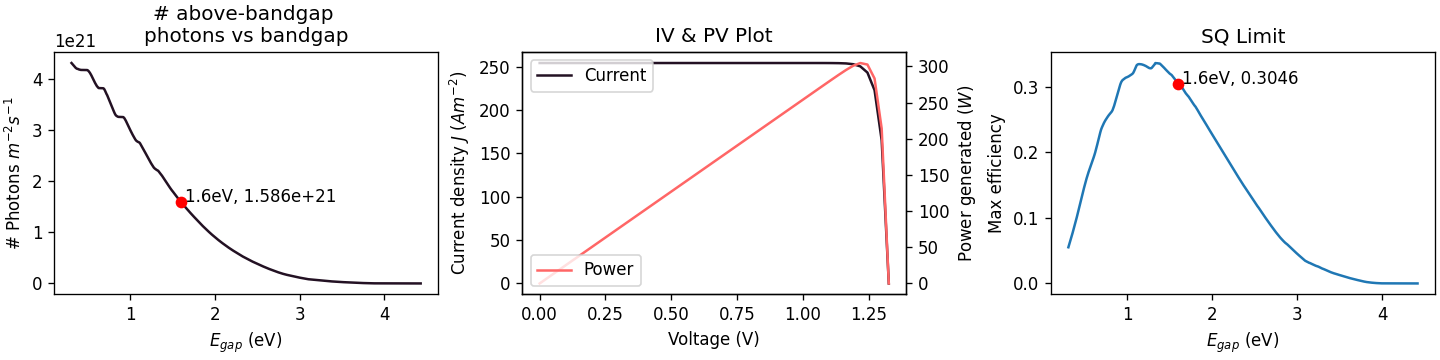

In [5]:
%matplotlib widget
db_plotting.plot_db_combined_interactive()

## Calculating the \<name\> Figure of Merit

In [5]:
E_gap = 1.45

Tcell = 300

fom = final_results.Crovetto_efficiency(E_gap, photon_spectrum, alpha_cm, tau, sigma, dos_mass, dop_density, epsilon, mu, Tcell)

NameError: name 'alpha_cm' is not defined